In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = np.arange(100)
X

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [25]:
# Min-Max normalization
def min_max_normalize(n: np.ndarray):
    return (n - n.min(axis=0))/(n.max(axis=0) - n.min(axis=0))

X2 = min_max_normalize(X)
X2

array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404,
       0.05050505, 0.06060606, 0.07070707, 0.08080808, 0.09090909,
       0.1010101 , 0.11111111, 0.12121212, 0.13131313, 0.14141414,
       0.15151515, 0.16161616, 0.17171717, 0.18181818, 0.19191919,
       0.2020202 , 0.21212121, 0.22222222, 0.23232323, 0.24242424,
       0.25252525, 0.26262626, 0.27272727, 0.28282828, 0.29292929,
       0.3030303 , 0.31313131, 0.32323232, 0.33333333, 0.34343434,
       0.35353535, 0.36363636, 0.37373737, 0.38383838, 0.39393939,
       0.4040404 , 0.41414141, 0.42424242, 0.43434343, 0.44444444,
       0.45454545, 0.46464646, 0.47474747, 0.48484848, 0.49494949,
       0.50505051, 0.51515152, 0.52525253, 0.53535354, 0.54545455,
       0.55555556, 0.56565657, 0.57575758, 0.58585859, 0.5959596 ,
       0.60606061, 0.61616162, 0.62626263, 0.63636364, 0.64646465,
       0.65656566, 0.66666667, 0.67676768, 0.68686869, 0.6969697 ,
       0.70707071, 0.71717172, 0.72727273, 0.73737374, 0.74747

In [30]:
def z_score_standardize(n: np.ndarray):
    return ((n - n.mean(axis=0))/n.std(axis=0))

X3 = z_score_standardize(X)
print('Mean is ', X3.mean(), 'srd is: ', X3.std())
X3

Mean is  4.440892098500626e-18 srd is:  1.0


array([-1.71481604, -1.68017329, -1.64553055, -1.6108878 , -1.57624505,
       -1.5416023 , -1.50695955, -1.4723168 , -1.43767406, -1.40303131,
       -1.36838856, -1.33374581, -1.29910306, -1.26446031, -1.22981757,
       -1.19517482, -1.16053207, -1.12588932, -1.09124657, -1.05660382,
       -1.02196108, -0.98731833, -0.95267558, -0.91803283, -0.88339008,
       -0.84874733, -0.81410459, -0.77946184, -0.74481909, -0.71017634,
       -0.67553359, -0.64089084, -0.6062481 , -0.57160535, -0.5369626 ,
       -0.50231985, -0.4676771 , -0.43303435, -0.39839161, -0.36374886,
       -0.32910611, -0.29446336, -0.25982061, -0.22517786, -0.19053512,
       -0.15589237, -0.12124962, -0.08660687, -0.05196412, -0.01732137,
        0.01732137,  0.05196412,  0.08660687,  0.12124962,  0.15589237,
        0.19053512,  0.22517786,  0.25982061,  0.29446336,  0.32910611,
        0.36374886,  0.39839161,  0.43303435,  0.4676771 ,  0.50231985,
        0.5369626 ,  0.57160535,  0.6062481 ,  0.64089084,  0.67

In [31]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X_raw = 2 * np.random.rand(100, 3)
noise = np.random.randn(100) * 5
y =  3 * X_raw[:, 0] + noise

print(f"X shape: {X_raw.shape}")
print(f"y shape: {y.shape}")

X shape: (100, 3)
y shape: (100,)


In [32]:
X_normalized = min_max_normalize(X_raw)

print("Min-Max Normalization Results:")
print(f"Min per feature: {X_normalized.min(axis=0)}")
print(f"Max per feature: {X_normalized.max(axis=0)}")

Min-Max Normalization Results:
Min per feature: [0. 0. 0.]
Max per feature: [1. 1. 1.]


In [34]:
X_standardized = z_score_standardize(X_raw)

print("Z-score Standardization Results:")
print(f"Mean per feature: {X_standardized.mean(axis=0).round(4)}")
print(f"Std per feature: {X_standardized.std(axis=0).round(4)}")

Z-score Standardization Results:
Mean per feature: [-0.  0. -0.]
Std per feature: [1. 1. 1.]


In [37]:
import copy
def compute_cost(X, y, w, b): 
    m = X.shape[0]
    cost = 0.0
    for i in range(m):                                
        f_wb_i = np.dot(X[i], w) + b 
        cost = cost + (f_wb_i - y[i])**2     
    cost = cost / (2 * m)                         
    return cost

def compute_gradient(w, b, x, y):
    m, n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0
    for i in range(m):
        dj_db += (w @ x[i] + b - y[i])
        for j in range(n):
            dj_dw += (np.dot(w, x[i]) + b - y[i])*x[i,j]
    return dj_dw/m, dj_db/m

def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    j_history = []
    b = b_in
    w = copy.deepcopy(w_in)
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)
        b = b - alpha * dj_db
        w = w - alpha * dj_dw
        j_history.append(compute_cost(X, y, w, b))
    return w, b, j_history


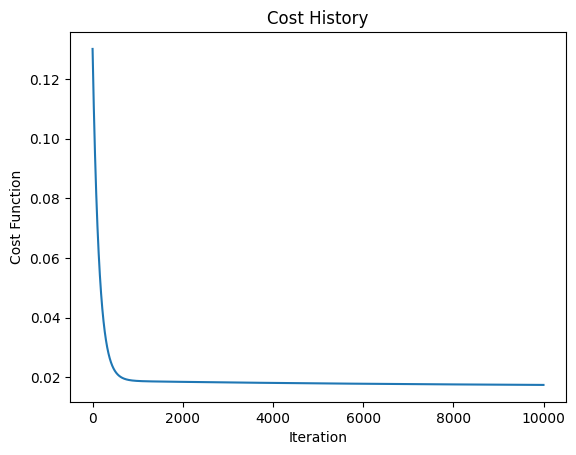

w:  [0.15270565 0.15270565 0.15270565] b:  0.23316169650284269


In [44]:
w, b, j_history = gradient_descent(min_max_normalize(X_raw), min_max_normalize(y), np.zeros(X_raw.shape[1]), 0, 0.001, 10000)
plt.plot(j_history)
plt.title("Cost History")
plt.xlabel("Iteration")
plt.ylabel("Cost Function")
plt.show()
print('w: ', w, 'b: ', b)